# Auto-scaling score machines (ASLS, ASELS)

Compare inference of **ASLS** and **ASELS** (autoscaling LS/ELS) against **LS**, **ELS**, and **NN** on the same white noise samples.

**ASLS / ASELS** compute LS (or ELS) at all scales in `k_vals`, then Boltzmann-weight the score outputs by energy
$$E_k = \beta_{\mathrm{scale}} \cdot \mathrm{SNR} \cdot \mathrm{Var}(\varphi)_k - S[p(\varphi|\phi)]_k$$
where Var is the center-pixel variance and \(S\) is the posterior entropy at scale \(k\). Lower energy → higher weight.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

os.chdir("../")
ROOT = Path(os.path.abspath("")).resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
from src.utils.data import get_dataset
from src.utils.idealscore import (
    LocalScoreModule,
    LocalEquivScoreModule,
    LocalEquivBordersScoreModule,
    AutoscalingLSModule,
    AutoscalingELSModule,
    AutoscalingBBELSModule,
    ScheduledScoreMachine,
)
from src.utils.noise_schedules import cosine_noise_schedule
from src.utils.channel_theory import load_scale_calibration

In [3]:
# Config
dataset_name = "mnist"
# Set to True if GPU is busy/unavailable (e.g. CUDA error) to run on CPU.
force_cpu = False
if force_cpu:
    device = torch.device("cpu")
else:
    try:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if device.type == "cuda":
            torch.zeros(1, device=device).item()  # probe GPU; may raise if busy
    except Exception:
        device = torch.device("cpu")
        print("CUDA unavailable or busy,why using CPU.")
nsteps = 20
num_samples = 4
k_vals = (3, 5, 7, 9, 11)
beta_scale = 5.0
max_samples = 2000
score_batch_size = 64
tld = "./checkpoints/"

In [4]:
dataset, metadata = get_dataset(dataset_name, root=str(ROOT / "data"))
in_channels = metadata["num_channels"]
image_size = metadata["image_size"]
schedule = cosine_noise_schedule
name_upper = metadata["name"].upper()

## Build machines: LS, ELS, ASLS, ASELS, NN

LS and ELS use calibrated scales (one k per step). ASLS and ASELS use no scales and autoscale at each step. NN uses the same scales as LS/ELS if available.

In [5]:
# Scales file (median k per step); try dataset-specific then fallback
scale_candidates = [
    f"scales_{name_upper}_ResNet_zeros_median.pt",
    f"scales_{name_upper}_ResNet_zeros.pt"
]
scales = None
for cand in scale_candidates:
    p = ROOT / tld / cand
    if p.exists():
        scales_data = torch.load(p, map_location="cpu", weights_only=False)
        scales = [int(s) for s in (scales_data.int().numpy() if isinstance(scales_data, torch.Tensor) else scales_data)]
        print(f"Loaded scales from {cand}, nsteps={len(scales)}")
        break
if scales is None:
    print("No scales file found; LS/ELS will use default_time_steps without per-step k.")

Loaded scales from scales_MNIST_ResNet_zeros.pt, nsteps=20


In [6]:
# LS backbone + machine (with scales if available)
ls_backbone = LocalScoreModule(
    dataset,
    kernel_size=k_vals[0],
    image_size=image_size,
    batch_size=min(score_batch_size, len(dataset)),
    schedule=schedule,
    max_samples=max_samples,
)
machine_ls = ScheduledScoreMachine(
    ls_backbone,
    in_channels=in_channels,
    imsize=image_size,
    noise_schedule=schedule,
    score_backbone=True,
    scales=scales,
    default_time_steps=nsteps,
)
machine_ls.to(device)
machine_ls.eval()

ScheduledScoreMachine(
  (backbone): LocalScoreModule()
)

In [7]:
# ELS backbone + machine
els_backbone = LocalEquivScoreModule(
    dataset,
    kernel_size=k_vals[0],
    batch_size=score_batch_size,
    image_size=image_size,
    channels=in_channels,
    schedule=schedule,
    max_samples=max_samples,
)
machine_els = ScheduledScoreMachine(
    els_backbone,
    in_channels=in_channels,
    imsize=image_size,
    noise_schedule=schedule,
    score_backbone=True,
    scales=scales,
    default_time_steps=nsteps,
)
machine_els.to(device)
machine_els.eval()

ScheduledScoreMachine(
  (backbone): LocalEquivScoreModule()
)

In [8]:
# Boundary broken ELS (bbELS): ELS with boundary zeros
bbels_backbone = LocalEquivBordersScoreModule(
    dataset,
    kernel_size=k_vals[0],
    batch_size=score_batch_size,
    image_size=image_size,
    channels=in_channels,
    schedule=schedule,
    max_samples=max_samples,
)
machine_bbels = ScheduledScoreMachine(
    bbels_backbone,
    in_channels=in_channels,
    imsize=image_size,
    noise_schedule=schedule,
    score_backbone=True,
    scales=scales,
    default_time_steps=nsteps,
)
machine_bbels.to(device)
machine_bbels.eval()

ScheduledScoreMachine(
  (backbone): LocalEquivBordersScoreModule(
    (local_module): LocalScoreModule()
  )
)

In [9]:
# bbASELS: autoscaling boundary ELS (uniform weighting over k_vals)
bbasels_backbone = AutoscalingBBELSModule(
    dataset,
    k_vals=k_vals,
    image_size=image_size,
    channels=in_channels,
    batch_size=score_batch_size,
    schedule=schedule,
    max_samples=max_samples,
)
machine_bbasels = ScheduledScoreMachine(
    bbasels_backbone,
    in_channels=in_channels,
    imsize=image_size,
    noise_schedule=schedule,
    score_backbone=True,
    scales=None,
    default_time_steps=nsteps,
)
machine_bbasels.to(device)
machine_bbasels.eval()

ScheduledScoreMachine(
  (backbone): AutoscalingBBELSModule(
    (base): LocalEquivBordersScoreModule(
      (local_module): LocalScoreModule()
    )
  )
)

In [10]:
# ASLS: autoscaling LS (no scales; beta_scale used in Boltzmann weighting)
asls_backbone = AutoscalingLSModule(
    dataset,
    k_vals=k_vals,
    beta_scale=beta_scale,
    image_size=image_size,
    batch_size=min(score_batch_size, len(dataset)),
    schedule=schedule,
    max_samples=max_samples,
)
machine_asls = ScheduledScoreMachine(
    asls_backbone,
    in_channels=in_channels,
    imsize=image_size,
    noise_schedule=schedule,
    score_backbone=True,
    scales=None,
    default_time_steps=nsteps,
)
machine_asls.to(device)
machine_asls.eval()

ScheduledScoreMachine(
  (backbone): AutoscalingLSModule(
    (base): LocalScoreModule()
  )
)

In [11]:
# ASELS: autoscaling ELS
asels_backbone = AutoscalingELSModule(
    dataset,
    k_vals=k_vals,
    beta_scale=beta_scale,
    image_size=image_size,
    channels=in_channels,
    batch_size=score_batch_size,
    schedule=schedule,
    max_samples=max_samples,
)
machine_asels = ScheduledScoreMachine(
    asels_backbone,
    in_channels=in_channels,
    imsize=image_size,
    noise_schedule=schedule,
    score_backbone=True,
    scales=None,
    default_time_steps=nsteps,
)
machine_asels.to(device)
machine_asels.eval()

ScheduledScoreMachine(
  (backbone): AutoscalingELSModule(
    (base): LocalEquivScoreModule()
  )
)

In [12]:
# NN backbone (optional): load from checkpoint if present
# Checkpoints were saved with class module "models"; register so unpickler can find it.
import src.models
sys.modules["models"] = sys.modules["src.models"]
import src.utils
sys.modules["utils"] = sys.modules["src.utils"]

nn_backbone = None
for name in [f"backbone_{name_upper}_ResNet_zeros.pt", f"backbone_{name_upper}_ResNet_zeros.pt"]:
    p = ROOT / tld / name
    if p.exists():
        nn_backbone = torch.load(p, map_location=device, weights_only=False)
        if hasattr(nn_backbone, "backbone"):
            nn_backbone = nn_backbone.backbone
        nn_backbone.eval()
        print(f"Loaded NN backbone from {name}")
        break
if nn_backbone is not None:
    # NN was trained to predict noise (epsilon), not score; use score_backbone=False
    machine_nn = ScheduledScoreMachine(
        nn_backbone,
        in_channels=in_channels,
        imsize=image_size,
        noise_schedule=schedule,
        score_backbone=False,
        scales=scales,
        default_time_steps=nsteps,
    )
    machine_nn.to(device)
    machine_nn.eval()
else:
    machine_nn = None
    print("No NN checkpoint found; skipping NN comparison.")

Loaded NN backbone from backbone_MNIST_ResNet_zeros.pt


## Same white noise seeds → run all machines

In [13]:
torch.manual_seed(123)
seeds = torch.randn(num_samples, in_channels, image_size, image_size, device=device)
results = {}

In [14]:
lst = results.get("LS", [])
if isinstance(lst, torch.Tensor):
    lst = []
with torch.no_grad():
    for i in range(num_samples):
        x0 = seeds[i : i + 1].clone()
        lst = lst + [machine_ls(x0, nsteps=nsteps, device=device).cpu()]
    results["LS"] = torch.cat(lst, dim=0)

In [15]:
lst = results.get("ELS", [])
if isinstance(lst, torch.Tensor):
    lst = []
with torch.no_grad():
    for i in range(num_samples):
        x0 = seeds[i : i + 1].clone()
        lst = lst + [machine_els(x0, nsteps=nsteps, device=device).cpu()]
    results["ELS"] = torch.cat(lst, dim=0)

In [16]:
lst = results.get("ASLS", [])
if isinstance(lst, torch.Tensor):
    lst = []
with torch.no_grad():
    for i in range(num_samples):
        x0 = seeds[i : i + 1].clone()
        lst = lst + [machine_asls(x0, nsteps=nsteps, device=device).cpu()]
    results["ASLS"] = torch.cat(lst, dim=0)

In [17]:
lst = results.get("ASELS", [])
if isinstance(lst, torch.Tensor):
    lst = []
with torch.no_grad():
    for i in range(num_samples):
        x0 = seeds[i : i + 1].clone()
        lst = lst + [machine_asels(x0, nsteps=nsteps, device=device).cpu()]
    results["ASELS"] = torch.cat(lst, dim=0)

In [18]:
if machine_nn is not None:
    lst = results.get("NN", [])
    if isinstance(lst, torch.Tensor):
        lst = []
    with torch.no_grad():
        for i in range(num_samples):
            x0 = seeds[i : i + 1].clone()
            lst = lst + [machine_nn(x0, nsteps=nsteps, device=device).cpu()]
        results["NN"] = torch.cat(lst, dim=0)

In [19]:
lst = results.get("bbELS", [])
if isinstance(lst, torch.Tensor):
    lst = []
with torch.no_grad():
    for i in range(num_samples):
        x0 = seeds[i : i + 1].clone()
        lst = lst + [machine_bbels(x0, nsteps=nsteps, device=device).cpu()]
    results["bbELS"] = torch.cat(lst, dim=0)

In [20]:
lst = results.get("bbASELS", [])
if isinstance(lst, torch.Tensor):
    lst = []
with torch.no_grad():
    for i in range(num_samples):
        x0 = seeds[i : i + 1].clone()
        lst = lst + [machine_bbasels(x0, nsteps=nsteps, device=device).cpu()]
    results["bbASELS"] = torch.cat(lst, dim=0)

## Compare samples (same seed per column)

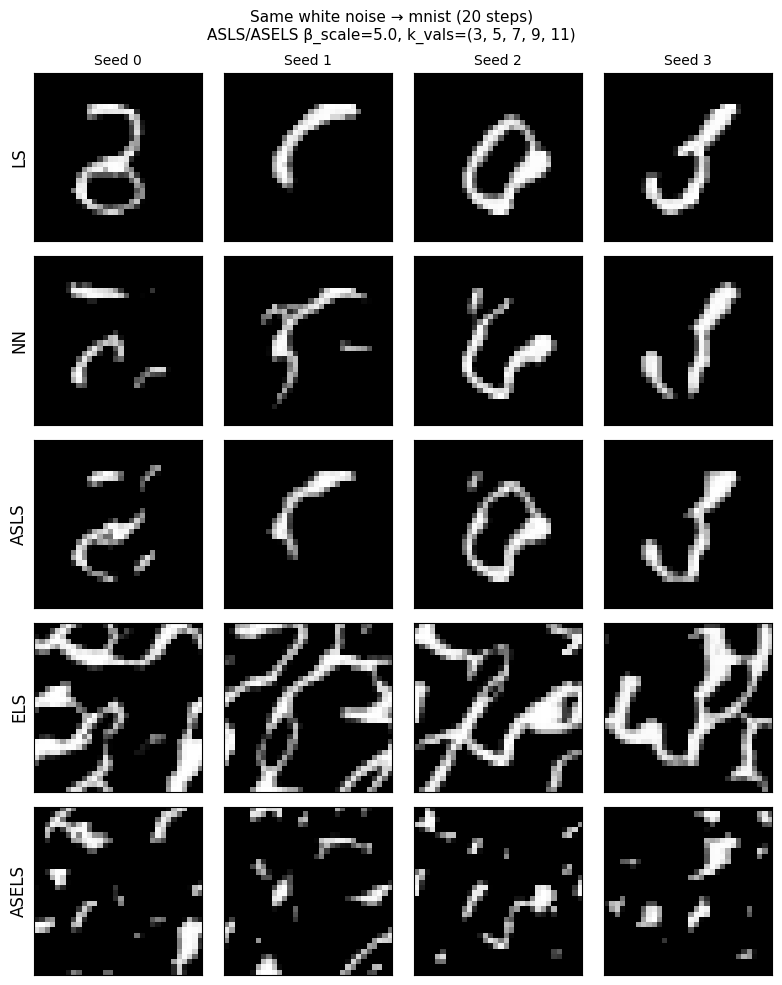

In [21]:
def to_show(x):
    """(C,H,W) or (N,C,H,W) -> numpy for imshow; clip to [0,1]."""
    if x.dim() == 4:
        x = x[0]
    x = x.cpu().numpy()
    x = np.clip(x, 0, 1)
    if x.shape[0] == 1:
        return x[0]
    return np.transpose(x, (1, 2, 0))

methods = ["LS", "NN","ASLS", "ELS", "ASELS"]
nrows = len(methods)
ncols = num_samples
fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
if nrows == 1:
    axes = axes[None, :]
for r, method in enumerate(methods):
    out = results[method]
    for c in range(ncols):
        ax = axes[r, c]
        ax.imshow(to_show(out[c : c + 1]), cmap="gray" if in_channels == 1 else None)
        ax.set_xticks([])
        ax.set_yticks([])
        if c == 0:
            ax.set_ylabel(method, fontsize=12)
        if r == 0:
            ax.set_title(f"Seed {c}", fontsize=10)
plt.suptitle(f"Same white noise → {dataset_name} ({nsteps} steps)\nASLS/ASELS β_scale={beta_scale}, k_vals={k_vals}", fontsize=11)
plt.tight_layout()
plt.show()

## Compare LS, NN, ASLS, and boundary broken ELS (bbELS)

Same seeds; bbELS uses ELS with boundary zeros (LocalEquivBordersScoreModule).

## Compare bbELS, NN, and bbASELS

Three-way comparison on the same seeds; bbASELS = autoscaling boundary ELS (uniform blend over scales).

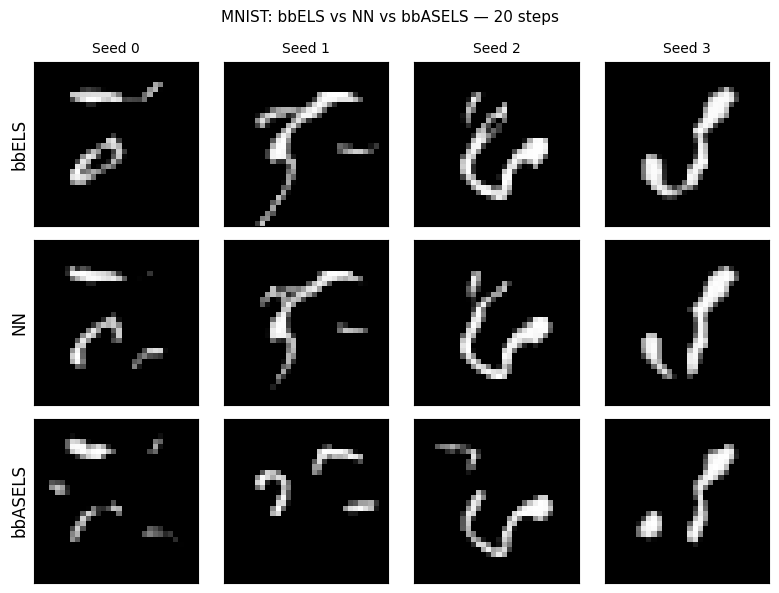

In [22]:
# bbELS vs NN vs bbASELS (dataset in title)
methods_3 = ["bbELS", "NN", "bbASELS"]
nrows_3 = len(methods_3)
fig3, axes3 = plt.subplots(nrows_3, ncols, figsize=(2 * ncols, 2 * nrows_3))
if nrows_3 == 1:
    axes3 = axes3[None, :]
for r, method in enumerate(methods_3):
    out = results[method]
    for c in range(ncols):
        ax = axes3[r, c]
        ax.imshow(to_show(out[c : c + 1]), cmap="gray" if in_channels == 1 else None)
        ax.set_xticks([])
        ax.set_yticks([])
        if c == 0:
            ax.set_ylabel(method, fontsize=12)
        if r == 0:
            ax.set_title(f"Seed {c}", fontsize=10)
plt.suptitle(f"{name_upper}: bbELS vs NN vs bbASELS — {nsteps} steps", fontsize=11)
plt.tight_layout()
plt.show()

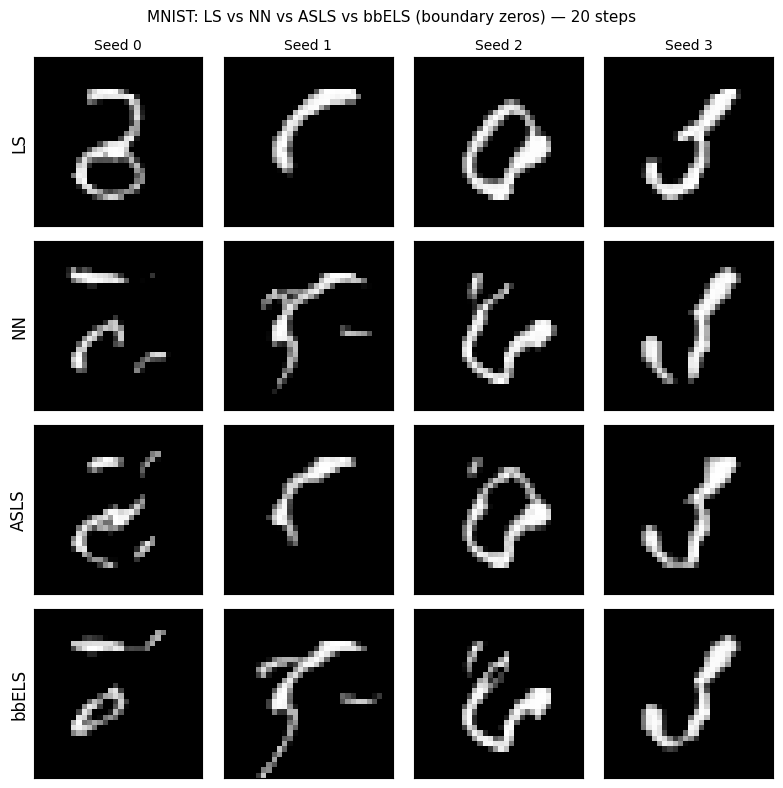

In [23]:
# Four-way comparison: LS, NN, ASLS, bbELS (dataset in title per project rules)
methods_4 = ["LS", "NN", "ASLS", "bbELS"]
nrows_4 = len(methods_4)
fig4, axes4 = plt.subplots(nrows_4, ncols, figsize=(2 * ncols, 2 * nrows_4))
if nrows_4 == 1:
    axes4 = axes4[None, :]
for r, method in enumerate(methods_4):
    out = results[method]
    for c in range(ncols):
        ax = axes4[r, c]
        ax.imshow(to_show(out[c : c + 1]), cmap="gray" if in_channels == 1 else None)
        ax.set_xticks([])
        ax.set_yticks([])
        if c == 0:
            ax.set_ylabel(method, fontsize=12)
        if r == 0:
            ax.set_title(f"Seed {c}", fontsize=10)
plt.suptitle(f"{name_upper}: LS vs NN vs ASLS vs bbELS (boundary zeros) — {nsteps} steps", fontsize=11)
plt.tight_layout()
plt.show()

$$E_k(\phi) = \beta_{scale}\gamma_{SNR} Var(\varphi | \phi)_k) - S[p_k(\varphi | \phi)]$$
$$\mathbf{s}_{ASLS}(\phi) = \frac{\sum_{k} exp(-E_k(\phi)) \mathbf{s}_{LS, k}(\phi)}{\sum_{k} exp(-E_k(\phi))}$$

$$k$$